In [334]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [335]:
import numpy as np
from scipy.ndimage import gaussian_filter, uniform_filter, median_filter
from scipy.signal import savgol_filter

try:
    from skimage.restoration import denoise_tv_chambolle, denoise_bilateral
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False


def _nan_gaussian(arr, sigma, truncate=3.0, mode='reflect'):
    """Gaussian smoothing that ignores NaNs via normalized convolution."""
    a = np.asarray(arr, float)
    w = np.isfinite(a).astype(float)
    a = np.where(np.isfinite(a), a, 0.0)

    num = gaussian_filter(a, sigma=sigma, truncate=truncate, mode=mode)
    den = gaussian_filter(w, sigma=sigma, truncate=truncate, mode=mode)
    out = num / np.maximum(den, 1e-12)
    out[den == 0] = np.nan
    return out


def _nan_uniform(arr, size, mode='reflect'):
    a = np.asarray(arr, float)
    w = np.isfinite(a).astype(float)
    a = np.where(np.isfinite(a), a, 0.0)

    num = uniform_filter(a, size=size, mode=mode)
    den = uniform_filter(w, size=size, mode=mode)
    out = num / np.maximum(den, 1e-12)
    out[den == 0] = np.nan
    return out


def smooth2d(arr, method='gaussian', **kwargs):
    """
    2-D smoothing for beam pattern maps with NaN handling.

    Parameters
    ----------
    arr : 2D array
        Input array (amplitude or intensity). If you have dB values,
        convert to linear, smooth, then convert back to dB to avoid bias.
    method : str
        'gaussian' (default), 'uniform', 'median', 'savgol', 'tv', or 'bilateral'.
    kwargs :
        gaussian: sigma=<float or (sy,sx) in pixels>, truncate=3.0, mode='reflect'
        uniform : size=<int or (sy,sx)>, mode='reflect'
        median  : size=<int or (sy,sx)>
        savgol  : window_length_y, window_length_x (odd ints), polyorder=2, mode='interp'
        tv      : weight (e.g., 0.1–0.3), eps, n_iter_max (requires scikit-image)
        bilateral: sigma_color, sigma_spatial, bins (requires scikit-image)

    Returns
    -------
    2D array, same shape as input.
    """
    method = method.lower()
    if method == 'gaussian':
        sigma = kwargs.get('sigma', 1.0)
        truncate = kwargs.get('truncate', 3.0)
        mode = kwargs.get('mode', 'reflect')
        return _nan_gaussian(arr, sigma=sigma, truncate=truncate, mode=mode)

    elif method == 'uniform':
        size = kwargs.get('size', 3)
        mode = kwargs.get('mode', 'reflect')
        return _nan_uniform(arr, size=size, mode=mode)

    elif method == 'median':
        size = kwargs.get('size', 3)
        a = np.asarray(arr, float)
        # fill NaNs with local median via two-pass trick
        nanmask = ~np.isfinite(a)
        filled = a.copy()
        if nanmask.any():
            # rough fill with 0 for median filter, then reinsert NaNs where kernel had none
            tmp = median_filter(np.nan_to_num(a, nan=0.0), size=size)
            filled[nanmask] = tmp[nanmask]
        out = median_filter(filled, size=size)
        out[nanmask] = np.nan  # keep NaNs where no information existed
        return out

    elif method == 'savgol':
        wy = kwargs.get('window_length_y', 7)  # must be odd
        wx = kwargs.get('window_length_x', 7)  # must be odd
        poly = kwargs.get('polyorder', 2)
        a = np.asarray(arr, float)
        # simple NaN handling: inpaint with gaussian first, then Savitzky–Golay separably
        a0 = _nan_gaussian(a, sigma=1.0)  # gentle fill
        out = savgol_filter(a0, wy, poly, axis=0, mode='interp')
        out = savgol_filter(out, wx, poly, axis=1, mode='interp')
        return out

    elif method == 'tv':
        if not _HAS_SKIMAGE:
            raise ImportError("scikit-image is required for 'tv' (denoise_tv_chambolle).")
        weight = kwargs.get('weight', 0.15)  # larger => more smoothing
        eps = kwargs.get('eps', 2e-4)
        n_iter = kwargs.get('n_iter_max', 200)
        a = np.asarray(arr, float)
        a0 = _nan_gaussian(a, sigma=1.0)  # fill NaNs mildly
        out = denoise_tv_chambolle(a0, weight=weight, eps=eps, max_num_iter=n_iter, channel_axis=None)
        out[~np.isfinite(arr)] = np.nan
        return out

    elif method == 'bilateral':
        if not _HAS_SKIMAGE:
            raise ImportError("scikit-image is required for 'bilateral' (denoise_bilateral).")
        sigma_color = kwargs.get('sigma_color', 0.05)
        sigma_spatial = kwargs.get('sigma_spatial', 2)
        a = np.asarray(arr, float)
        a0 = _nan_gaussian(a, sigma=1.0)
        out = denoise_bilateral(a0, sigma_color=sigma_color, sigma_spatial=sigma_spatial, channel_axis=None)
        out[~np.isfinite(arr)] = np.nan
        return out

    else:
        raise ValueError(f"Unknown method: {method}")

In [336]:
path_to_data_f40 = '../data/watertank/p200_f40_r1mm.mat'
path_to_data_f60 = '../data/watertank/p200_f60_r1mm.mat'    
data_f40 = sio.loadmat(path_to_data_f40)
data_f60 = sio.loadmat(path_to_data_f60)
key = "ppmean"
data_2d_f40 = np.array(data_f40[key])
data_2d_f60 = np.array(data_f60[key])
square_data = False

In [337]:
# grid
dy = 2
dx = 1
ny, nx = data_2d_f40.shape
print(f"nx: {nx}, ny: {ny}")

#x = np.linspace(-nx/2*dx, nx/2*dx, nx)
x = np.linspace(-8, 6, nx)
y = np.linspace(dy, ny*dy, ny)
xticklabels = np.round(x, 1)
yticklabels = np.round(y, 1)

# cast y to int
yticklabels = yticklabels.astype(int)

x

nx: 15, ny: 45


array([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,
        5.,  6.])

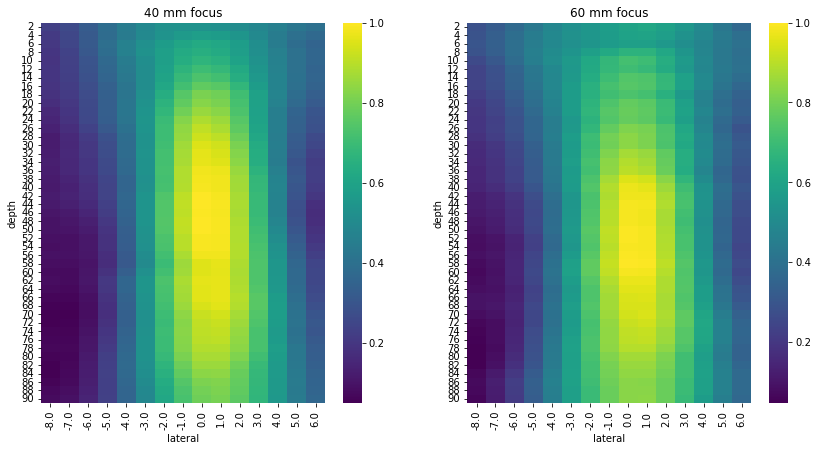

In [338]:
# interpolate the data to make it smoother
colormap = 'viridis'
method = 'gaussian'
data_2d_f40 = smooth2d(data_2d_f40, method=method, sigma=1)
data_2d_f60 = smooth2d(data_2d_f60, method=method, sigma=1)

# identify the maximum value in the data
max_value_f40 = np.max(data_2d_f40)
max_value_f60 = np.max(data_2d_f60)

# normalize the data to the maximum value
data_2d_f40 = data_2d_f40 / max_value_f40
data_2d_f60 = data_2d_f60 / max_value_f60

# identify the pixel with the maximum value
max_pixel_f40 = np.unravel_index(np.argmax(data_2d_f40), data_2d_f40.shape)
max_pixel_f60 = np.unravel_index(np.argmax(data_2d_f60), data_2d_f60.shape)

# square the data to bring it from voltage to power
if square_data:
    data_2d_f40 = data_2d_f40**2
    data_2d_f60 = data_2d_f60**2

fig, ax = plt.subplots(1,2,figsize=(14,7))
# add x and y labels matching X and Y grids
sns.heatmap(data_2d_f40, cmap=colormap, ax=ax[0], xticklabels=xticklabels, yticklabels=yticklabels)
ax[0].set_title('40 mm focus')
ax[0].set_xlabel('lateral')
ax[0].set_ylabel('depth')

#ax[0].scatter(max_pixel_f40[1], max_pixel_f40[0], color='red', marker='x')

sns.heatmap(data_2d_f60, cmap='viridis', ax=ax[1], xticklabels=xticklabels, yticklabels=yticklabels)
ax[1].set_title('60 mm focus')
ax[1].set_xlabel('lateral')
ax[1].set_ylabel('depth')


# indicate the maximum value
#ax[1].scatter(max_pixel_f60[1], max_pixel_f60[0], color='red', marker='x')






plt.show()


In [339]:
x[0],x[-1]

(np.float64(-8.0), np.float64(6.0))

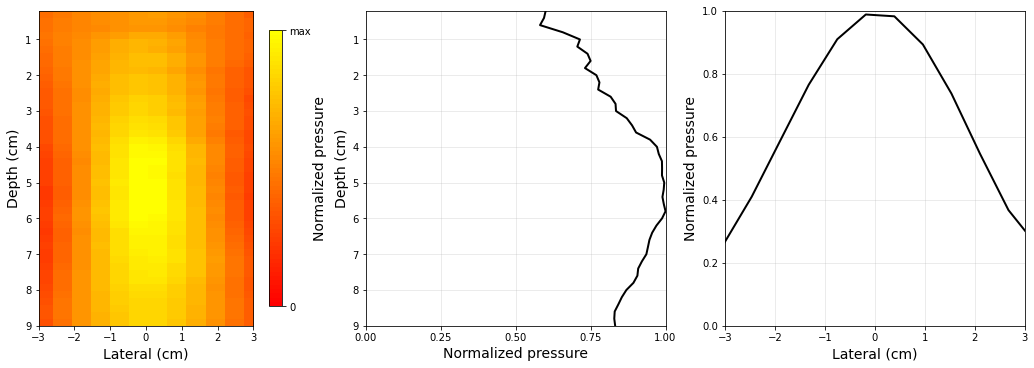

In [344]:
# Publication-ready 60 mm focus plots (side-by-side panels, corrected grid)
# Lateral: 1 cm per step; depth axis unchanged (y in mm → cm labels)
colormap = 'autumn'
colormap_levels = 64  # adjust to control the number of discrete colors
cmap_obj = plt.get_cmap(colormap, colormap_levels)

x_cm = (np.arange(data_2d_f60.shape[1]) - (data_2d_f60.shape[1]-1)/2) * 1.0  # 1 cm per column

x_start_cm = -4.75
x_end_cm = 3.25
x_cm = np.linspace(x_start_cm, x_end_cm, nx)

try:
    y_cm = y / 10.0  # y defined earlier in mm
except NameError:
    y_cm = np.arange(data_2d_f60.shape[0]) * 0.2  # fallback if y not in scope

label_font = {'fontsize': 14}

# Heatmap + midline profile + lateral profile (linear pressure, normalized to peak)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Heatmap
im = axes[0].imshow(
    data_2d_f60,
    cmap=cmap_obj,
    origin='upper',
    extent=[x_cm.min(), x_cm.max(), y_cm.max(), y_cm.min()],
    aspect='equal',
    vmin=0,
    vmax=1,
)
axes[0].set_xlim(-3, 3)
axes[0].set_xticks(np.arange(-3, 4, 1))
axes[0].set_xlabel('Lateral (cm)', fontdict=label_font)

yticks_cm = np.arange(np.ceil(y_cm.min()), np.floor(y_cm.max()) + 0.1, 1)
axes[0].set_yticks(yticks_cm)
axes[0].set_ylabel('Depth (cm)', fontdict=label_font)

cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Normalized pressure', labelpad=2, fontdict=label_font)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', 'max'])

# Midline pressure vs depth
mid_idx = data_2d_f60.shape[1] // 2 + 1
profile = data_2d_f60[:, mid_idx]
axes[1].plot(profile, y_cm, color='black', lw=2)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(y_cm.max(), y_cm.min())  # depth increases downward to mirror heatmap
axes[1].set_xlabel('Normalized pressure', fontdict=label_font)
axes[1].set_ylabel('Depth (cm)', fontdict=label_font)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0])
axes[1].set_yticks(yticks_cm)

# Lateral profile at ~6 cm depth
target_depth_cm = 6.0
depth_idx = int(np.argmin(np.abs(y_cm - target_depth_cm)))
lat_profile = data_2d_f60[depth_idx, :]
axes[2].plot(x_cm, lat_profile, color='black', lw=2)
axes[2].set_xlim(x_cm.min(), x_cm.max())
axes[2].set_xlim(-3, 3)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Lateral (cm)', fontdict=label_font)
axes[2].set_ylabel('Normalized pressure', fontdict=label_font)
axes[2].grid(True, alpha=0.3)
#axes[2].set_xticks(np.arange(np.floor(x_cm.min()), np.ceil(x_cm.max()) + 0.1, 1))

plt.show()


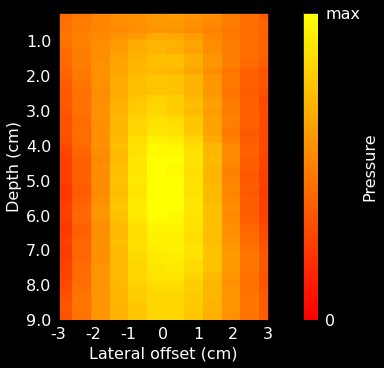

In [368]:
# Publication-ready 60 mm focus plots (side-by-side panels, corrected grid)
# Lateral: 1 cm per step; depth axis unchanged (y in mm → cm labels)
label_font = {'fontsize': 20}

colormap = 'autumn'
colormap_levels = 64  # adjust to control the number of discrete colors
cmap_obj = plt.get_cmap(colormap, colormap_levels)

x_cm = (np.arange(data_2d_f60.shape[1]) - (data_2d_f60.shape[1]-1)/2) * 1.0  # 1 cm per column

x_start_cm = -4.75
x_end_cm = 3.25
x_cm = np.linspace(x_start_cm, x_end_cm, nx)

try:
    y_cm = y / 10.0  # y defined earlier in mm
except NameError:
    y_cm = np.arange(data_2d_f60.shape[0]) * 0.2  # fallback if y not in scope

label_font = {'fontsize': 16, 'color': 'white'}

# Heatmap + midline profile + lateral profile (linear pressure, normalized to peak)
fig, ax = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True, facecolor='black')

# Heatmap
im = ax.imshow(
    data_2d_f60,
    cmap=cmap_obj,
    origin='upper',
    extent=[x_cm.min(), x_cm.max(), y_cm.max(), y_cm.min()],
    aspect='equal',
    vmin=0,
    vmax=1,
)
ax.set_xlim(-3, 3)
ax.set_xticks(np.arange(-3, 4, 1))
ax.set_xticklabels(np.arange(-3, 4, 1), color='white', fontdict=label_font)
ax.set_xlabel('Lateral offset (cm)', fontdict=label_font)

yticks_cm = np.arange(np.ceil(y_cm.min()), np.floor(y_cm.max()) + 0.1, 1)
ax.set_yticks(yticks_cm)
ax.set_yticklabels(yticks_cm, color='white', fontdict=label_font)
ax.set_ylabel('Depth (cm)', fontdict=label_font)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pressure', labelpad=2, fontdict=label_font)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', 'max'], color='white', fontdict=label_font)

# make the background black


#axes[2].set_xticks(np.arange(np.floor(x_cm.min()), np.ceil(x_cm.max()) + 0.1, 1))
fig.savefig('../figures/beampattern_2d.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


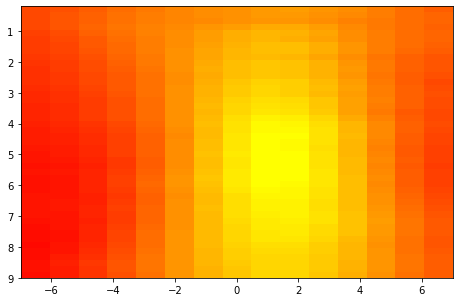

In [343]:
# High-res 2-D beampattern (colormap only) for square multipanel SVG
import numpy as np
import matplotlib.pyplot as plt

# Grid in cm (recompute to avoid dependency on prior cells)
x_cm = (np.arange(data_2d_f60.shape[1]) - (data_2d_f60.shape[1]-1)/2) * 1.0
try:
    y_cm = y / 10.0  # y defined earlier in mm
except NameError:
    y_cm = np.arange(data_2d_f60.shape[0]) * 0.2  # fallback if y not in scope

# Colormap with controllable levels if available
cmap_name = 'autumn'
try:
    cmap_name = colormap
except NameError:
    pass
try:
    cmap_levels = colormap_levels
    cmap_obj = plt.get_cmap(cmap_name, cmap_levels)
except Exception:
    cmap_obj = plt.get_cmap(cmap_name)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    data_2d_f60,
    cmap=cmap_obj,
    origin='upper',
    extent=[x_cm.min(), x_cm.max(), y_cm.max(), y_cm.min()],
    aspect='equal',
    vmin=0,
    vmax=1,
)
ax.set_xlim(x_cm.min(), x_cm.max())
ax.set_ylim(y_cm.max(), y_cm.min())
#ax.axis('off')
fig.subplots_adjust(0, 0, 1, 1)

# Save high-res SVG for multipanel layouts
plt.savefig('../figures/beampattern_2d.svg', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()
